### Contexto e Objetivo

Está sendo desenvolvido um modelo de classificação de dados em uma base de serviço para avaliar se um cliente irá continuar no serviço ou irá cancelá-lo. Essa analise poderá ser util para identificar as chances do cliente querer desistir do serviço que possui, e avaliar os fatores que podem afetar nessa decisão


Importação de Dependências

In [160]:
from functions import gini_coeficient, lorenz_curve
import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

from lightgbm import LGBMClassifier


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [161]:
df_credit = pd.read_csv(r"..\\documents\\Credit_Card_Churn.csv")

# Análise Inicial da base de Crédito

In [162]:
# Não apresenta nenhum valor nulo

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

Análise de valores únicos

In [163]:
for x in df_credit.columns:
    print(f'Coluna: {x}')
    print(np.sort(df_credit[x].unique()), "\n")
    

Coluna: CLIENTNUM
[100000000 100000001 100000002 ... 100009997 100009998 100009999] 

Coluna: Attrition_Flag
['Attrited Customer' 'Existing Customer'] 

Coluna: Customer_Age
[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 

Coluna: Gender
['F' 'M'] 

Coluna: Dependent_count
[0 1 2 3 4 5] 

Coluna: Education_Level
['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated'] 

Coluna: Marital_Status
['Divorced' 'Married' 'Single'] 

Coluna: Income_Category
['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown'] 

Coluna: Card_Category
['Blue' 'Gold' 'Platinum' 'Silver'] 

Coluna: Months_on_book
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60] 

Coluna: Total_Relationship_Count
[1 2 3 4 5 6] 

Coluna: Months_Inactive_12_mon
[0 1 2 3 4 5 6] 

Coluna: 

Avaliar se o dataset apresenta valores negativos

In [164]:
colunas_numericas = [c for c in df_credit.columns if df_credit[c].dtype != 'object']

print("Colunas com valores abaixo de 0:")

for c in colunas_numericas:
    if (df_credit[c] < 0).any():
        print(c)


Colunas com valores abaixo de 0:
Avg_Open_To_Buy


In [165]:
# Análise percentual de clientes que cancelaram o cartão de crédito

df_credit['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.85
Attrited Customer    0.15
Name: proportion, dtype: float64

In [166]:
# Análise percentual de clientes que cancelaram o cartão de crédito por tipo de cartão

df_credit.groupby("Card_Category")['Attrition_Flag'].value_counts(normalize=True)

Card_Category  Attrition_Flag   
Blue           Existing Customer    0.84
               Attrited Customer    0.16
Gold           Existing Customer    0.87
               Attrited Customer    0.13
Platinum       Existing Customer    0.90
               Attrited Customer    0.10
Silver         Existing Customer    0.86
               Attrited Customer    0.14
Name: proportion, dtype: float64

# Tratamento dos Dados

Nessa estapa está sendo adaptado as colunas em string para padrões numérico para avaliar o quanto elas se correlacionam entre si e então descartando as colunas que poderiam confundir o modelo

In [167]:
df_base_credit = df_credit.copy()

In [168]:

# Avaliação Oridnal-Encoding

# 1. Definição do mapeamento (Lista de listas para o OrdinalEncoder)
income_category_map = [["Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +"]]

# 2. Tratamento inicial de 'Unknown' (substituido por nulo)
df_base_credit['Income_Category'] = df_base_credit['Income_Category'].replace('Unknown', np.nan)


# 3. Configuração do Ordinal Encoder
# foi usado  handle_unknown='use_encoded_value' para evitar erros com valores inesperados
ordinal_encoder = OrdinalEncoder(
    categories=income_category_map,
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan
)

# 4. Aplicação da Transformação Ordinal
df_base_credit[['Income_Category']] = ordinal_encoder.fit_transform(df_base_credit[['Income_Category']])

# 5. Tratamento de Valores Ausentes
# foram substituidos valores nulos pela mediana dos valores mapeados
imputer = SimpleImputer(strategy='median') 
df_base_credit[['Income_Category']] = imputer.fit_transform(df_base_credit[['Income_Category']])


# Mapeamento de Educação
mapa_edu = {
    'Uneducated': 1, 'High School': 2, 'College': 3, 
    'Graduate': 4, 'Post-Graduate': 5, 'Doctorate': 6
}
df_base_credit['Education_Level'] = df_base_credit['Education_Level'].map(mapa_edu)


Foi criado um arquivo adaptado do Credit_Card_Churn onde a coluna Income_Category foi adaptada para numérica, de modo a endenter melhor quais colunas estão prejudicando os modelos por meio da plataforma Orange

In [169]:
df_base_credit.to_csv(r"..\\documents\\CREDIT_CARD_CHURN_ADAPTED.csv", index=False)

In [170]:
# Mapeamento da Coluna Target
atrition_flag_map = {
    'Attrited Customer': 1,
    'Existing Customer': 0
}
df_base_credit['Attrition_Flag'] = df_base_credit['Attrition_Flag'].apply(lambda x: atrition_flag_map[x])

In [171]:
# Avaliação One-Hot-Encoder
df_base_credit = pd.get_dummies(df_base_credit, drop_first=True)


#ohe = OneHotEncoder(sparse_output=False)

#dados_encoder = ohe.fit_transform(df_base_credit[['Gender','Education_Level','Marital_Status','Card_Category']])

#df_encoder_columns = pd.DataFrame(dados_encoder, columns=ohe.get_feature_names_out())

# União dos dados com os dataframes-One-Hot-Encoder
#df_base_credit = pd.concat([df_base_credit, df_encoder_columns], axis=1)

In [172]:
# Para melhorar o poder preditivo em relação aos modelos foi optado em
# incluir novas medidas e avaliar sua relação com a variável target


# 1) divisão do valor das transações pela quantidade de transações
df_base_credit['Avg_Trans'] = round(df_base_credit['Total_Trans_Amt']/df_base_credit['Total_Trans_Ct'],2)

# 2) Percentual de utilização do crédito efetivado
df_base_credit['Revolving_To_Limit_Credit'] = df_base_credit['Total_Revolving_Bal']/(df_base_credit['Credit_Limit'] + 1e-5)

# 3) Indicador de inatividades recentes
df_base_credit['Inactive_Contact_Score'] = df_base_credit['Contacts_Count_12_mon'] * df_base_credit['Months_Inactive_12_mon']

# 4) Indicador de Padrão de Consumo Próximo ao Churn
df_base_credit['Amt_CT_Chng_Q4_Q1'] = df_base_credit['Total_Amt_Chng_Q4_Q1'] * df_base_credit['Total_Ct_Chng_Q4_Q1']


In [173]:
# Renomeação de colunas

rename_map = { 'Gender_F': 'Is_Female', 'Gender_M': 'Is_Male',
            'Education_Level_College': 'Education_College',
            'Education_Level_Doctorate': 'Education_Doctorate', 
            'Education_Level_Graduate': 'Education_Graduate',
            'Education_Level_High School': 'Education_HighSchool', 
            'Education_Level_Post-Graduate': 'Education_Post_Graduate',
            'Education_Level_Uneducated': 'Is_Uneducated',

            'Marital_Status_Divorced': 'Status_Divorced',
            'Marital_Status_Married': 'Status_Married', 
            'Marital_Status_Single': 'Status_Single', 
            'Card_Category_Blue': 'Is_Blue_Card',
            'Card_Category_Gold': 'Is_Gold_Card', 
            'Card_Category_Platinum': 'Is_Platinum_Card', 
            'Card_Category_Silver': 'Is_Silver_Card'
          }

df_base_credit = df_base_credit.rename(columns=rename_map)

Correlação das variáveis


foram criados graficos Heatmap para:

* Identificar a Multicolinearidade entre as variáveis, ou seja, se duas dizem basicamente a mesma coisa, 
foi criado um grafico heatmap para

* Avaliar as colunas One-Hot-Encoding, (dividir um valor em string como 0 ou 1)

* Identificar as correlações altas


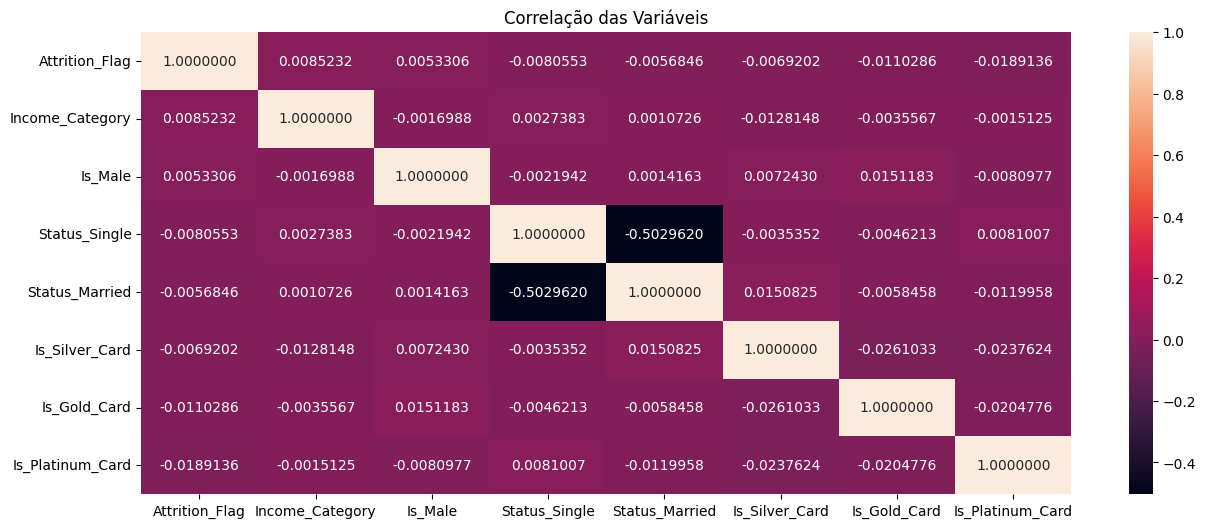

In [174]:
# Análise das colunas Label-Encoding e One-Hot-Encoding
df_encoding_correlations = df_base_credit[
                                ['Attrition_Flag', 'Income_Category','Is_Male', 
                                'Status_Single', 'Status_Married',
                               'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card'
                              ]].corr() 

plt.figure(figsize=(15, 6))

sns.heatmap(data=df_encoding_correlations, 
            annot=True, fmt=".7f", annot_kws={"size": 10})
plt.title("Correlação das Variáveis")
plt.show()

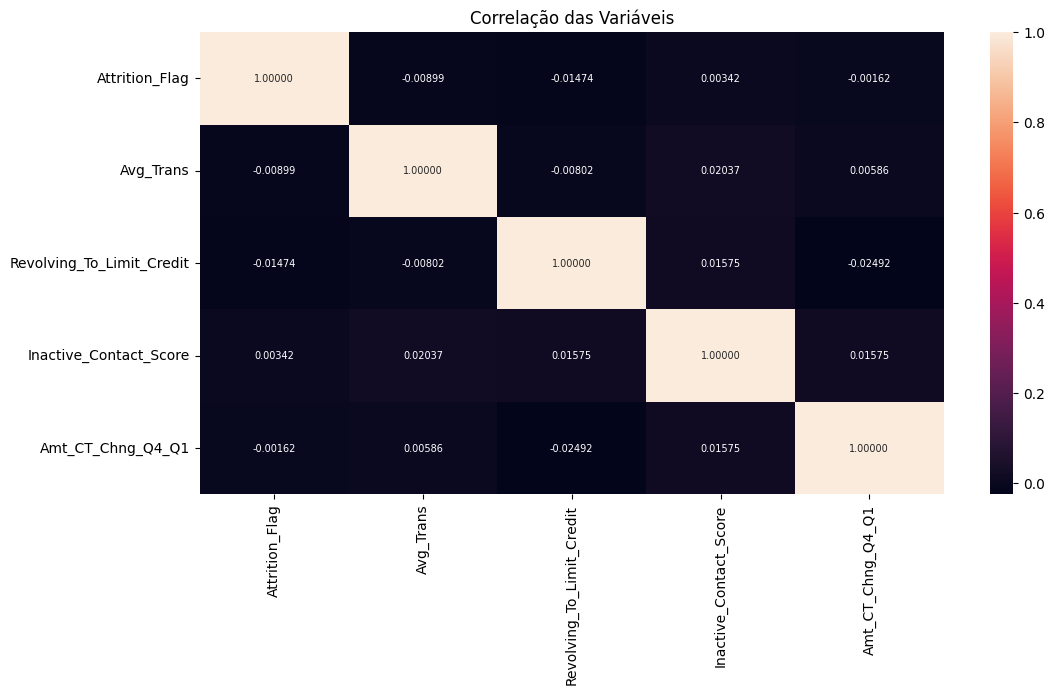

In [175]:
# Análise de Correlação da coluna Target com as novas colunas criadas

df_correlation_columns = df_base_credit[['Attrition_Flag', 'Avg_Trans',
                                         'Revolving_To_Limit_Credit',
                                         'Inactive_Contact_Score',
                                         'Amt_CT_Chng_Q4_Q1'
                                         ]].corr()


plt.figure(figsize=(12,6))

sns.heatmap(data=df_correlation_columns, 
            annot=True, fmt=".5f", annot_kws={"size": 7})
plt.title("Correlação das Variáveis")
plt.show()

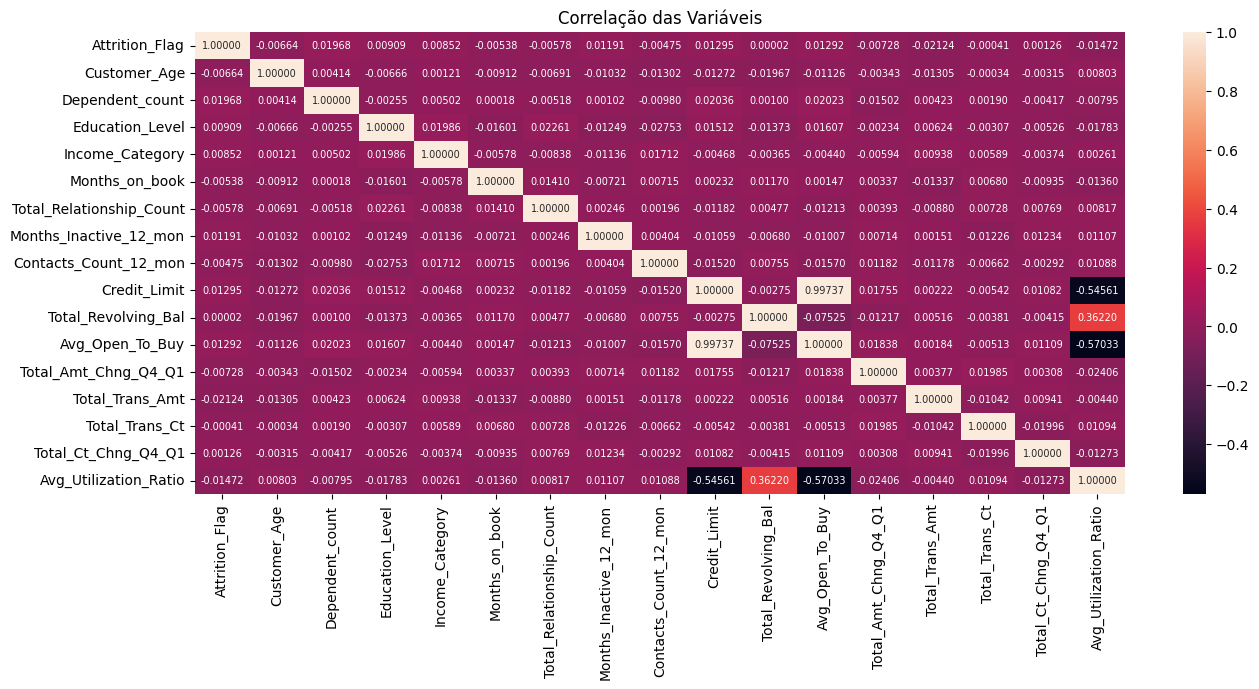

In [176]:
# Avaliação do resto das colunas

df_correlations = df_base_credit.drop(columns=['CLIENTNUM',
                                            'Is_Male', 
                                            'Status_Single', 'Status_Married',
                                            'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card',
                                            'Avg_Trans', 'Revolving_To_Limit_Credit',
                                            'Inactive_Contact_Score',
                                            'Amt_CT_Chng_Q4_Q1'
                                        ]).corr() 

#  'Is_Male', 'Education_Doctorate', 'Education_Graduate',
#       'Education_HighSchool', 'Education_Post_Graduate', 'Is_Uneducated',

# Education_College, Is_Female, Status_Divorced, Is_Blue_Card
# 'Gender', 'CLIENTNUM', 'Marital_Status', 'Card_Category', 'Education_Level',

plt.figure(figsize=(15, 6))

sns.heatmap(data=df_correlations, 
            annot=True, fmt=".5f", annot_kws={"size": 7})
plt.title("Correlação das Variáveis")
plt.show()

Conclusões

* A coluna CLIENTNUM foi removida do conjunto de dados por se tratar de
  um identificador de cliente. Por não gerar poder preditivo, poderá 
  causar Overfitting ou ruído entre modelos

* Foi identificado uma forte Multicolinearidade entre as
  colunas Avg_Open_To_Buy e Credit_Limit (aproximadamente 0.99).
  Foi decidido remover o Avg_Open_To_Buy, pois o Credit_Limit apresenta
  uma relação linear mais consistente com a variável alvo

* A coluna Customer_Age apresenta correlação linear
  desprezível com o Attrition_Flag, além de demonstrar redundância entre si. Foi 
  decidido remover essa coluna para simplificar o modelo

* pela coluna Avg_Trans apresentar correlação negativa com o Attrition_Flag,
além de indicar redundância entre as colunas 'Total_Trans_Ct' e 'Total_Trans_Amt'; poranto será removida

In [177]:
df_base_credit.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Dependent_count',
       'Education_Level', 'Income_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Is_Male', 'Status_Married', 'Status_Single', 'Is_Gold_Card',
       'Is_Platinum_Card', 'Is_Silver_Card', 'Avg_Trans',
       'Revolving_To_Limit_Credit', 'Inactive_Contact_Score',
       'Amt_CT_Chng_Q4_Q1'],
      dtype='object')

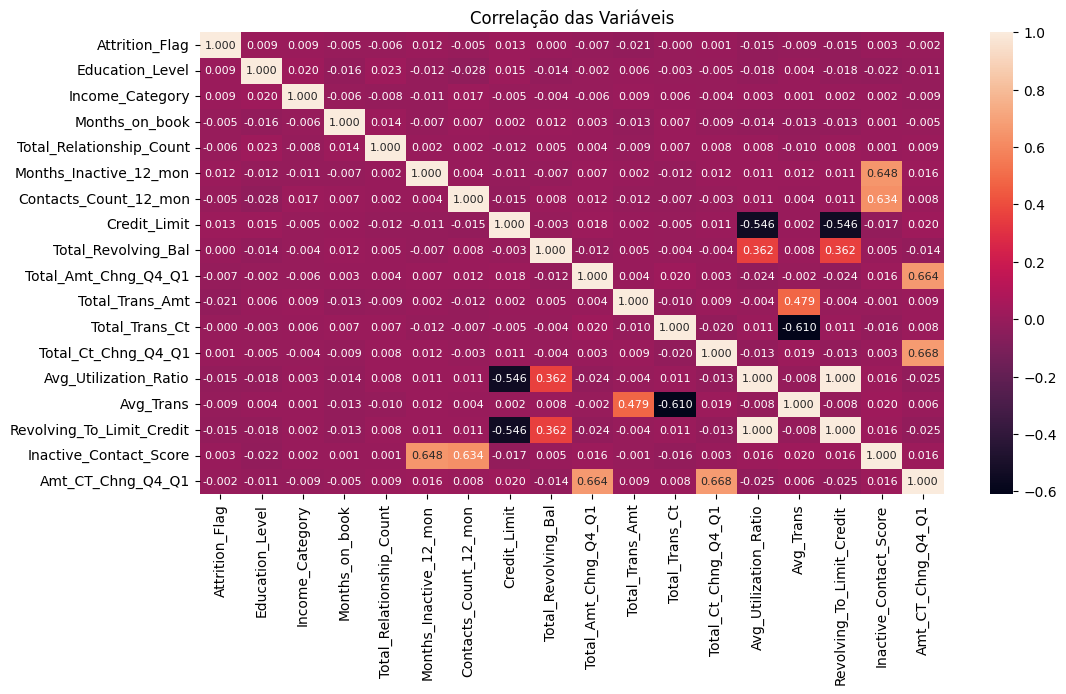

In [178]:
df_credit_clean = df_base_credit.drop(columns=[
                                        'CLIENTNUM','Avg_Open_To_Buy',
                                        'Customer_Age', 'Dependent_count',
                                        
                                        'Is_Male', 'Status_Married', 'Status_Single', 'Is_Gold_Card',
                                        'Is_Platinum_Card', 'Is_Silver_Card',


                                        #'Status_Single', 'Status_Married', 
                                        #'Is_Male'

                                        #'Customer_Age', 'Dependent_count', 
                                        #'Total_Trans_Amt',
                                        #'Education_Level',

                                        #'Status_Single', 'Status_Married',
                                        #'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card',
            
                                        # 'Education_Doctorate',  'Education_Graduate',
                                        # 'Education_HighSchool', 'Education_Post_Graduate',  
                                        # 'Is_Uneducated'
                                    ]) 

plt.figure(figsize=(12, 6))

sns.heatmap(data=df_credit_clean.corr(), 
            annot=True, fmt=".3f", annot_kws={"size": 8})
plt.title("Correlação das Variáveis")
plt.show()

Definição das variáveis de treino e teste

In [179]:
X = df_credit_clean.drop(columns=['Attrition_Flag'], axis=1)
y = df_credit_clean['Attrition_Flag']

# Será dividido os dados dos eixos x e y em 80% de treino e 20% de teste
# stratify -> variável alvo
# random_state -> trava o sorteio para ser sempre igual

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Modelo de Regressão Logística

In [180]:
# Deve ser aplicado o StandardScaler para que o Modelo de Regressão Logística
# consiga colocar todas as variáveis na mesma escala

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [181]:
# criação do modelo
logistic_regression = LogisticRegression(class_weight='balanced', max_iter=2000)

# treinamento do modelo
logistic_regression.fit(X_train_scalled, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [182]:

# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_lr = gini_coeficient(model=logistic_regression, X_test=X_test_scalled, Y_Test=Y_test)

# O Modelo é linear, seguindo o mapeamento {'Attrited Customer': 1,'Existing Customer': 0}
print(f'Coeficiente de Gini (Logistic Regression): {gini_lr}')

Area Under Reciver: 0.502596251266464
Coeficiente de Gini (Logistic Regression): 0.005192502532928023


In [183]:
# Previsão do modelo
pred_lr = logistic_regression.predict(X_test_scalled)

print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_lr, 
                                      target_names=["Churn", "Permaneceu"], zero_division=0)
            }")


Matriz de Confusão (Logistic Regression):
[[875 817]
 [155 153]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.85      0.52      0.64      1692
  Permaneceu       0.16      0.50      0.24       308

    accuracy                           0.51      2000
   macro avg       0.50      0.51      0.44      2000
weighted avg       0.74      0.51      0.58      2000



Avaliação do Limite apropriado

In [184]:
# Comparativo com os Limites do Logistic Regression

prob_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1]

for lmt in np.arange(0.1, 1, 0.1):
    print(f"Matriz de Confusão - Limite {lmt:.2f}")
    print(confusion_matrix(Y_test, (prob_lr > lmt).astype("int") ), "\n")


Matriz de Confusão - Limite 0.10
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.20
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.30
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.40
[[   0 1692]
 [   0  308]] 

Matriz de Confusão - Limite 0.50
[[875 817]
 [155 153]] 

Matriz de Confusão - Limite 0.60
[[1691    1]
 [ 308    0]] 

Matriz de Confusão - Limite 0.70
[[1692    0]
 [ 308    0]] 

Matriz de Confusão - Limite 0.80
[[1692    0]
 [ 308    0]] 

Matriz de Confusão - Limite 0.90
[[1692    0]
 [ 308    0]] 



In [185]:
pred_proba_lr = (prob_lr > 0.5).astype("int")

print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_proba_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_proba_lr, 
                                      target_names=["Churn", "Permaneceu"], zero_division=0)
            }")


Matriz de Confusão (Logistic Regression):
[[875 817]
 [155 153]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.85      0.52      0.64      1692
  Permaneceu       0.16      0.50      0.24       308

    accuracy                           0.51      2000
   macro avg       0.50      0.51      0.44      2000
weighted avg       0.74      0.51      0.58      2000



Precisão: Entre os casos que o modelo previu quantos estão corretos


In [186]:
# Análise de quais são as colunas que mais estão sendo utilizadas no modelo

df_importancia = pd.DataFrame({
    'Importância': logistic_regression.coef_[0]  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Amt_CT_Chng_Q4_Q1,8.37e-02
1,Education_Level,5.08e-02
2,Income_Category,4.31e-02
3,Months_Inactive_12_mon,4.21e-02
4,Credit_Limit,3.26e-02
5,Total_Trans_Ct,1.81e-02
6,Avg_Trans,1.14e-02
7,Contacts_Count_12_mon,6.66e-03
8,Total_Revolving_Bal,7.85e-04
9,Months_on_book,-7.00e-03


# Modelo Random Florest

In [ ]:
# criação do modelo
random_florest = RandomForestClassifier(
    n_estimators=1000, # quantidade de estimativas
    max_depth=10, # impede que os dados sejam decorados
    class_weight='balanced', # balanceamento de pesos
    random_state=42
) 

# treinar o modelo
random_florest.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [188]:
calibrated_rf = CalibratedClassifierCV(random_florest, method='sigmoid', cv=5)

calibrated_rf.fit(X_train, Y_train)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

Coeficiente de Gini

In [189]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_rf = gini_coeficient(model=random_florest, X_test=X_test, Y_Test=Y_test)
print(f'Coeficiente de Gini (Random Florest): {gini_rf}\n')

gini_calibrated_rf = gini_coeficient(model=calibrated_rf, X_test=X_test, Y_Test=Y_test)
print(f'Coeficiente de Gini (Calibrated Random Florest): {gini_calibrated_rf}')

Area Under Reciver: 0.48384874581683096
Coeficiente de Gini (Random Florest): -0.03230250836633808

Area Under Reciver: 0.509665423229253
Coeficiente de Gini (Calibrated Random Florest): 0.019330846458506024


Avaliação do Limite apropriado

In [190]:
prob_rf = random_florest.predict_proba(X_test)[:, 0]

for lmt in np.arange(0, 1, 0.1):
    print(f'Matriz de Confusão Limite {lmt:.2f}')
    print(f"{confusion_matrix(Y_test, (prob_rf > lmt).astype("int")  )}\n")


Matriz de Confusão Limite 0.00
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.10
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.20
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.30
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.40
[[   0 1692]
 [   0  308]]

Matriz de Confusão Limite 0.50
[[  19 1673]
 [   1  307]]

Matriz de Confusão Limite 0.60
[[1038  654]
 [ 194  114]]

Matriz de Confusão Limite 0.70
[[1650   42]
 [ 298   10]]

Matriz de Confusão Limite 0.80
[[1689    3]
 [ 308    0]]

Matriz de Confusão Limite 0.90
[[1692    0]
 [ 308    0]]



In [191]:
# Previsão do modelo
pred_rf = (prob_rf > 0.5).astype("int") 

print(f"Matriz de Confusão (Random Florest):\n{confusion_matrix(Y_test, pred_rf  )}\n")

print(f"Relatório Random Florest:\n {
                classification_report(
                    Y_test, pred_rf, target_names=['Churn', 'Permaneceu'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }")


Matriz de Confusão (Random Florest):
[[  19 1673]
 [   1  307]]

Relatório Random Florest:
               precision    recall  f1-score   support

       Churn       0.95      0.01      0.02      1692
  Permaneceu       0.16      1.00      0.27       308

    accuracy                           0.16      2000
   macro avg       0.55      0.50      0.15      2000
weighted avg       0.83      0.16      0.06      2000



In [192]:
rf_calibrated_importances = np.mean(
    [orig_model.estimator.feature_importances_  
     for orig_model in calibrated_rf.calibrated_classifiers_]
, axis=0)

pd.DataFrame({
    'Importância (RandomFlorest)': random_florest.feature_importances_ ,
    'Importância (RandomFlorest Calibrated)': rf_calibrated_importances
    }, index=X_train.columns
).reset_index(names='Coluna (RANDOM FLOREST)').sort_values(
    by='Importância (RandomFlorest Calibrated)', ascending=False)

,Coluna (RANDOM FLOREST),Importância (RandomFlorest),Importância (RandomFlorest Calibrated)
9,Total_Trans_Amt,0.09,0.08
6,Credit_Limit,0.08,0.08
16,Amt_CT_Chng_Q4_Q1,0.08,0.08
7,Total_Revolving_Bal,0.08,0.08
13,Avg_Trans,0.08,0.08
14,Revolving_To_Limit_Credit,0.08,0.08
8,Total_Amt_Chng_Q4_Q1,0.08,0.08
11,Total_Ct_Chng_Q4_Q1,0.07,0.07
10,Total_Trans_Ct,0.07,0.07
2,Months_on_book,0.06,0.06


# Modelo XGBoost Classifier

In [ ]:
# criação do modelo

xgboost_classifier = xgb.XGBClassifier(scale_pos_weight=5., random_state=42) 

# treinamento do modelo
xgboost_classifier.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
# treinar o modelo calibrado
xgb_callibred = CalibratedClassifierCV(estimator=xgboost_classifier, cv=5, method='sigmoid')

xgb_callibred.fit(X_train, Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[flo

In [195]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_xgboost = gini_coeficient(model=xgboost_classifier, X_test=X_test, Y_Test=Y_test)
print(f'Coeficiente de Gini (XGBOOST Classifier): {gini_xgboost}\n')

gini_xgboost_calibred = gini_coeficient(model=xgb_callibred, X_test=X_test, Y_Test=Y_test)
print(f'Coeficiente de Gini (XGBOOST Classifier Callibred): {gini_xgboost_calibred}')


Area Under Reciver: 0.4712915630468822
Coeficiente de Gini (XGBOOST Classifier): -0.05741687390623562

Area Under Reciver: 0.5271368702219765
Coeficiente de Gini (XGBOOST Classifier Callibred): 0.054273740443953056


Avaliação do Limite para Matriz de Confusão

In [196]:
prob_xgboost = xgboost_classifier.predict_proba(X_test)[:, 0]

for lmt in np.arange(0, 1, 0.1):
    print(f'Matriz de Confusão {lmt}')
    print(confusion_matrix(Y_test, (prob_xgboost > lmt).astype("int") ), "\n")

Matriz de Confusão 0.0
[[   0 1692]
 [   0  308]] 

Matriz de Confusão 0.1
[[   2 1690]
 [   0  308]] 

Matriz de Confusão 0.2
[[  13 1679]
 [   2  306]] 

Matriz de Confusão 0.30000000000000004
[[  44 1648]
 [   6  302]] 

Matriz de Confusão 0.4
[[  93 1599]
 [  11  297]] 

Matriz de Confusão 0.5
[[ 184 1508]
 [  23  285]] 

Matriz de Confusão 0.6000000000000001
[[ 329 1363]
 [  46  262]] 

Matriz de Confusão 0.7000000000000001
[[ 520 1172]
 [  81  227]] 

Matriz de Confusão 0.8
[[819 873]
 [144 164]] 

Matriz de Confusão 0.9
[[1253  439]
 [ 219   89]] 



In [197]:
# Previsão do modelo
#pred_xgboot = xgboot_classifier.predict(X_test)
pred_xgboost = (prob_xgboost > 0.5).astype("int") 

print(f"Matriz de Confusão:\n{confusion_matrix(Y_test, pred_xgboost)}\n")

print(f"Relatório XGBOOST Classifier:\n {
                classification_report(
                    Y_test, pred_xgboost, target_names=['Churn', 'Permaneceu'],
                    zero_division=0
                )
            }")


Matriz de Confusão:
[[ 184 1508]
 [  23  285]]

Relatório XGBOOST Classifier:
               precision    recall  f1-score   support

       Churn       0.89      0.11      0.19      1692
  Permaneceu       0.16      0.93      0.27       308

    accuracy                           0.23      2000
   macro avg       0.52      0.52      0.23      2000
weighted avg       0.78      0.23      0.21      2000



In [198]:
xgb_calibrated_importances = np.mean(
    [orig_model.estimator.feature_importances_  
     for orig_model in xgb_callibred.calibrated_classifiers_]
, axis=0)

pd.DataFrame({
    'Importância (XGBoost)': xgboost_classifier.feature_importances_ ,
    'Importância (XGBoost Calibrated)': xgb_calibrated_importances
    }, index=X_train.columns
).reset_index(names='Coluna (XGBoost)').sort_values(
    by='Importância (XGBoost Calibrated)', ascending=False)

,Coluna (XGBoost),Importância (XGBoost),Importância (XGBoost Calibrated)
14,Revolving_To_Limit_Credit,0.07,0.07
6,Credit_Limit,0.06,0.06
16,Amt_CT_Chng_Q4_Q1,0.07,0.06
10,Total_Trans_Ct,0.06,0.06
13,Avg_Trans,0.06,0.06
7,Total_Revolving_Bal,0.06,0.06
8,Total_Amt_Chng_Q4_Q1,0.06,0.06
11,Total_Ct_Chng_Q4_Q1,0.06,0.06
15,Inactive_Contact_Score,0.06,0.06
4,Months_Inactive_12_mon,0.06,0.06


In [199]:
importancia_media_calibrated = np.mean(
    [
    orig_model.estimator.feature_importances_ 
    for orig_model in xgb_callibred.calibrated_classifiers_
]
, axis=0)

pd.DataFrame({
    'Importância': importancia_media_calibrated 
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna (XGBoost Classifier Callibred)')

,Coluna (XGBoost Classifier Callibred),Importância
0,Revolving_To_Limit_Credit,0.07
1,Credit_Limit,0.06
2,Amt_CT_Chng_Q4_Q1,0.06
3,Total_Trans_Ct,0.06
4,Avg_Trans,0.06
5,Total_Revolving_Bal,0.06
6,Total_Amt_Chng_Q4_Q1,0.06
7,Total_Ct_Chng_Q4_Q1,0.06
8,Inactive_Contact_Score,0.06
9,Months_Inactive_12_mon,0.06


# Modelo LGBM CLASSIFIER

para tentar gerar resultados mais precisos com dados tabulares balanceados foi
apresentado o modelo LGBM Classifier

In [200]:
lgbm_classifier = LGBMClassifier(is_unbalance=True, random_state=42)

lgbm_classifier.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 1230, number of negative: 6770
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2390
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153750 -> initscore=-1.705487
[LightGBM] [Info] Start training from score -1.705487


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [201]:
gini_lgbm_classifier = gini_coeficient(model=lgbm_classifier, X_test=X_test, Y_Test=Y_test)

print(f'Coeficiente de Gini (LGBM CLassifier): {gini_lgbm_classifier}')

Area Under Reciver: 0.48786689079242274
Coeficiente de Gini (LGBM CLassifier): -0.024266218415154528
